## Imports and Setup

Importing required libraries and dependencies.

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

## Code

In [2]:
teacher = tf.keras.models.load_model(
    r"C:\Users\k nithin\Downloads\M.Tech Project\models\ResNet101_lentil_10.keras",
    compile=False
)

teacher.trainable = False
print("Teacher loaded and frozen")

Teacher loaded and frozen


In [3]:
print("Trainable variables in teacher:",
      len(teacher.trainable_variables))

Trainable variables in teacher: 0


In [4]:
TEACHER_HINT_LAYERS = [
     "conv1_relu", "conv2_block1_out"
]

In [5]:
teacher_feature_extractor = Model(
    inputs=teacher.input,
    outputs=[teacher.get_layer(name).output for name in TEACHER_HINT_LAYERS],
    name="teacher_feature_extractor"
)

teacher_feature_extractor.trainable = False

In [6]:
teacher_feature_extractor.summary()

Model: "teacher_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 86,656 (338.50 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 86,656 (338.50 KB)

In [7]:
student_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [10]:
STUDENT_HINT_LAYERS = ["conv1_relu", "conv2_block2_concat"]

In [11]:
student_feature_extractor = Model(
    inputs=student_base.input,
    outputs=[student_base.get_layer(name).output for name in STUDENT_HINT_LAYERS],
    name="student_feature_extractor"
)

In [12]:
teacher_channels = [
    teacher_feature_extractor.output[i].shape[-1]
    for i in range(2)
]

proj_layers = [
    tf.keras.layers.Conv2D(teacher_channels[0], kernel_size=1, padding="same", name="proj_0"),
    tf.keras.layers.Conv2D(teacher_channels[1], kernel_size=1, padding="same", name="proj_1"),
]

In [13]:
def projection_layer(x, out_channels, name):
    return tf.keras.layers.Conv2D(
        out_channels,
        kernel_size=1,
        padding="same",
        name=name
    )(x)

In [14]:
teacher_channels = [
    teacher_feature_extractor.output[i].shape[-1]
    for i in range(len(teacher_feature_extractor.output))
]

print("Teacher channels:", teacher_channels)

Teacher channels: [64, 256]


In [15]:
student_features_raw = student_feature_extractor.output

In [16]:
projected_student_features = []

for i, s_feat in enumerate(student_features_raw):

    student_channels = s_feat.shape[-1]
    teacher_ch = teacher_channels[i]

    if student_channels != teacher_ch:
        s_feat = tf.keras.layers.Conv2D(
            teacher_ch,
            kernel_size=1,
            padding="same",
            name=f"proj_{i}"
        )(s_feat)

    projected_student_features.append(s_feat)

## Imports and Setup

Importing required libraries and dependencies.

In [17]:
import numpy as np

dummy_x = np.random.rand(2, 224, 224, 3).astype("float32")

teacher_feats = teacher_feature_extractor(dummy_x)
student_feats = student_feature_extractor(dummy_x)

for i, (tf, sf) in enumerate(zip(teacher_feats, student_feats)):
    print(f"\nLayer {i}")
    print("Teacher shape:", tf.shape)
    print("Student shape:", sf.shape)


Layer 0
Teacher shape: (2, 112, 112, 64)
Student shape: (2, 112, 112, 64)

Layer 1
Teacher shape: (2, 56, 56, 256)
Student shape: (2, 56, 56, 128)


## Code

In [18]:
for i, (tf, sf) in enumerate(zip(teacher_feats, student_feats)):
    print(f"\nLayer {i}")
    print("Teacher mean/std:", tf.numpy().mean(), tf.numpy().std())
    print("Student mean/std:", sf.numpy().mean(), sf.numpy().std())


Layer 0
Teacher mean/std: 1.6357294 1.5718527
Student mean/std: 0.07454239 0.06588684

Layer 1
Teacher mean/std: 0.8137304 0.6595281
Student mean/std: 0.01516567 0.17497346


In [19]:
def normalize_feature(f):
    mean = tf.reduce_mean(f, axis=[1, 2], keepdims=True)
    std = tf.math.reduce_std(f, axis=[1, 2], keepdims=True) + 1e-6
    return (f - mean) / std

In [20]:
def feature_kd_loss(teacher_feats, student_feats):
    loss = 0.0
    for t_feat, s_feat in zip(teacher_feats, student_feats):
        t_feat = tf.stop_gradient(normalize_feature(t_feat))
        s_feat = normalize_feature(s_feat)
        loss += tf.reduce_mean(tf.square(t_feat - s_feat))
    return loss

In [21]:
NUM_CLASSES = 3

## Imports and Setup

Importing required libraries and dependencies.

In [22]:
import tensorflow as tf
x = student_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(4, activation="relu")(x)
x = tf.keras.layers.Dropout(0.8)(x)
student_logits = Dense(NUM_CLASSES, activation=None, name="bean_logits")(x)

## Model Architecture

Building the DenseNet121 model with transfer learning. Using ImageNet pre-trained weights with custom classification head for the disease classes.

In [23]:
student_features_raw = student_feature_extractor.output

student_features_projected = [
    proj_layers[i](student_features_raw[i])
    for i in range(len(student_features_raw))
]

student_model = Model(
    inputs=student_base.input,
    outputs={
        "logits": student_logits,
        "features": student_features_projected
    }
)

## Imports and Setup

Importing required libraries and dependencies.

In [24]:
import tensorflow as tf

## Code

In [25]:
classification_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

In [26]:
KD_WEIGHT = 0.2

In [27]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

In [28]:
def train_step(images, labels):
    teacher_feats = teacher_feature_extractor(images)

    with tf.GradientTape() as tape:
        outputs = student_model(images, training=True)
        student_logits = outputs["logits"]
        student_feats = outputs["features"]

        cls_loss = classification_loss_fn(labels, student_logits)
        kd_loss = feature_kd_loss(teacher_feats, student_feats)

        total_loss = cls_loss + KD_WEIGHT * kd_loss

    grads = tape.gradient(total_loss, student_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, student_model.trainable_variables))

    return {
        "total_loss": total_loss,
        "cls_loss": cls_loss,
        "kd_loss": kd_loss
    }

In [29]:
dummy_y = tf.constant([0, 1])

losses = train_step(dummy_x, dummy_y)
print(losses)

{'total_loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.4792335033416748>, 'cls_loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.7750378847122192>, 'kd_loss': <tf.Tensor: shape=(), dtype=float32, numpy=3.5209779739379883>}


## Imports and Setup

Importing required libraries and dependencies.

In [30]:
import tensorflow as tf
import pathlib

DATA_DIR = pathlib.Path(r"C:\Users\k nithin\Downloads\M.Tech Project\Beans dataset")
IMG_SIZE = (224,224)
BATCH_SIZE = 8
SEED = 42
NUM_CLASSES = 3

## Data Loading and Preprocessing

Loading the dataset and applying preprocessing (normalization, augmentation, etc.).

In [31]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="training"
)

Found 59069 files belonging to 3 classes.
Using 41349 files for training.


In [32]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="validation"
)

Found 59069 files belonging to 3 classes.
Using 17720 files for validation.


## Code

In [33]:
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

In [34]:
class_names = train_ds.class_names
print("Class order:", class_names)

Class order: ['anthra', 'healthy', 'rust']


In [35]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
print("Train batches per epoch:", train_batches)
print("Approx images per epoch:", train_batches * BATCH_SIZE)

Train batches per epoch: 5169
Approx images per epoch: 41352


## Imports and Setup

Importing required libraries and dependencies.

In [36]:
from tensorflow.keras.applications.resnet import preprocess_input

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

## Code

In [37]:
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [38]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## Imports and Setup

Importing required libraries and dependencies.

In [39]:
import time

images, labels = next(iter(train_ds))

start = time.time()
losses = train_step(images, labels)
end = time.time()

print("One train_step time (seconds):", end - start)
print(losses)

One train_step time (seconds): 9.380291223526001
{'total_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.9482877254486084>, 'cls_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.205203056335449>, 'kd_loss': <tf.Tensor: shape=(), dtype=float32, numpy=3.715423583984375>}


## Code

In [40]:
STEPS_PER_EPOCH = 40
EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    step = 0
    for images, labels in train_ds:
        losses = train_step(images, labels)
        step += 1

        if step >= STEPS_PER_EPOCH:
            break

    print(
        f"Train | total: {losses['total_loss']:.4f} | "
        f"cls: {losses['cls_loss']:.4f} | "
        f"kd: {losses['kd_loss']:.4f}"
    )

    val_cls_loss = tf.keras.metrics.Mean()
    val_acc = tf.keras.metrics.SparseCategoricalAccuracy()

    for images, labels in val_ds:
        outputs = student_model(images, training=False)
        logits = outputs["logits"]

        loss = classification_loss_fn(labels, logits)
        val_cls_loss.update_state(loss)
        val_acc.update_state(labels, logits)

    print(
        f"Val   | cls_loss: {val_cls_loss.result():.4f} | "
        f"acc: {val_acc.result():.4f}"
    )


Epoch 1/10
Train | total: 1.6919 | cls: 0.9679 | kd: 3.6200
Val   | cls_loss: 2.2849 | acc: 0.2634

Epoch 2/10
Train | total: 2.3716 | cls: 1.6698 | kd: 3.5091
Val   | cls_loss: 1.6197 | acc: 0.3360

Epoch 3/10
Train | total: 1.6285 | cls: 0.9629 | kd: 3.3282
Val   | cls_loss: 0.9023 | acc: 0.5434

Epoch 4/10
Train | total: 1.4614 | cls: 0.8310 | kd: 3.1523
Val   | cls_loss: 0.7126 | acc: 0.6299

Epoch 5/10
Train | total: 1.6727 | cls: 1.0696 | kd: 3.0156
Val   | cls_loss: 0.7330 | acc: 0.6363

Epoch 6/10
Train | total: 1.5827 | cls: 1.0025 | kd: 2.9010
Val   | cls_loss: 0.7121 | acc: 0.6394

Epoch 7/10
Train | total: 1.5441 | cls: 0.9939 | kd: 2.7509
Val   | cls_loss: 0.6907 | acc: 0.6333

Epoch 8/10
Train | total: 1.2093 | cls: 0.6915 | kd: 2.5887
Val   | cls_loss: 0.6402 | acc: 0.6392

Epoch 9/10
Train | total: 1.3783 | cls: 0.8825 | kd: 2.4793
Val   | cls_loss: 0.6509 | acc: 0.6372

Epoch 10/10
Train | total: 1.1262 | cls: 0.6611 | kd: 2.3255
Val   | cls_loss: 0.6340 | acc: 0.6333

## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    outputs = student_model(images, training=False)
    logits = outputs["logits"]

    probs = tf.nn.softmax(logits)

    y_prob.extend(probs.numpy())
    y_pred.extend(np.argmax(probs.numpy(), axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

## Imports and Setup

Importing required libraries and dependencies.

In [42]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.6298554652213189


## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

c:\Users\k nithin\Downloads\M.Tech Project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\k nithin\Downloads\M.Tech Project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\k nithin\Downloads\M.Tech Project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

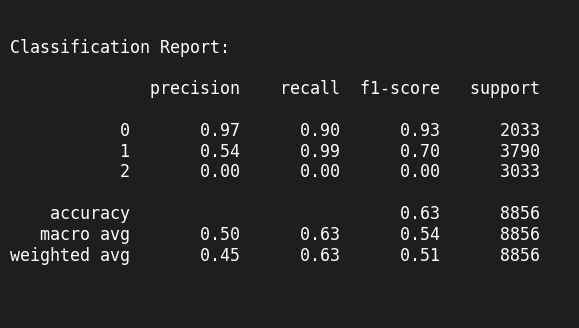

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

report_text = "Classification Report:\n\n" + classification_report(y_true, y_pred)

fig = plt.figure(figsize=(7, 4))
fig.patch.set_facecolor('#1e1e1e')

plt.text(0.1, 0.5, report_text, 
         color='white', 
         fontsize=12, 
         family='monospace', 
         transform=fig.transFigure, 
         verticalalignment='center')

plt.axis('off')

plt.savefig('terminal_classification_report.png', facecolor=fig.get_facecolor(), bbox_inches='tight', dpi=300)
plt.show()

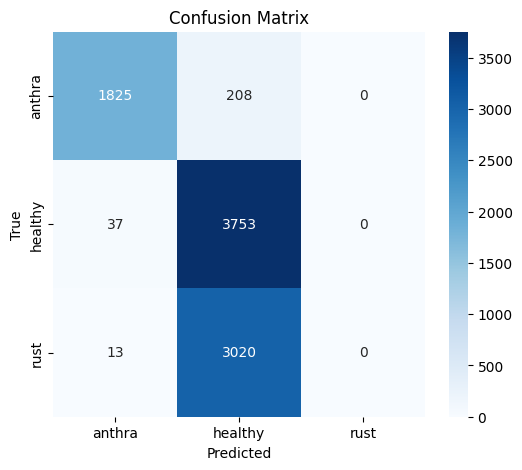

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Imports and Setup

Importing required libraries and dependencies.

In [45]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

## Code

In [46]:
roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9692786493009363


## Performance Metrics

Visualizing training curves and computing detailed metrics (confusion matrix, precision, recall, F1-score).

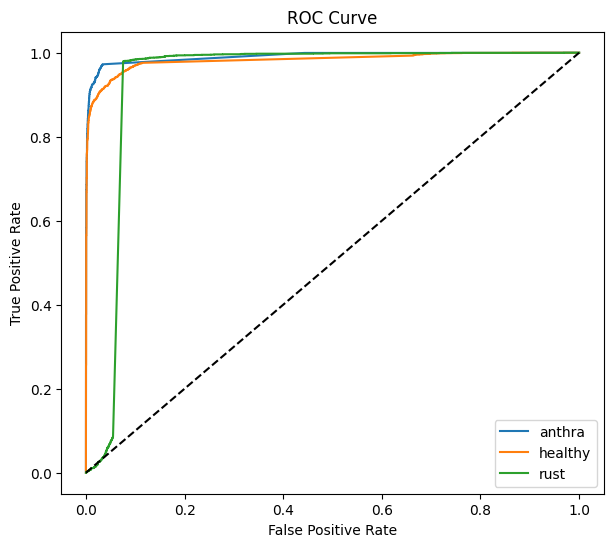

In [47]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Code